# 第021讲 联合分布与相关结构

## Goal
从同一次状态的多个坐标开始，核验联合、边缘与条件的区别；把协方差与条件高斯写成可检查的矩阵程序。所有模型是无量纲合成教学模型。本Notebook不使用外部数据、网络、GPU或付费API。

执行后的主要结果：六态协方差为 [[17/9,4/9],[4/9,2/9]]；全方差为 17/9=1+8/9；高斯在 x=5 时的条件均值为1、方差为27/4。模拟值会偏离理论值，相关接近0不能证明独立。

## Setup
先按 lab.pdf 或 README.md 安装环境，在本单元目录打开本文件。选择 Restart Kernel and Run All，不能依赖以前执行留下的变量。

### Key Assumptions
样本按行，坐标按列。所用二阶矩有限。密度和分块条件接口只接收数值上良好的严格正定协方差；奇异高斯通过显式线性因子生成。本文件保留实际执行输出，绘图的英文轴名保证未安装中文字体时仍可读。

In [1]:
%matplotlib inline
from pathlib import Path
import sys, math, json
from fractions import Fraction as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
candidates = [Path.cwd(), Path.cwd() / 'units' / '021']
unit_dir = next((p for p in candidates if (p / 'experiment.py').is_file() and (p / 'data' / 'joint_states.csv').is_file()), None)
if unit_dir is None:
    raise RuntimeError('Open this notebook from unit 021 or the course repository root.')
if str(unit_dir) not in sys.path:
    sys.path.insert(0, str(unit_dir))
import experiment as e
from test_experiment import run_checks
plt.rcParams.update({'figure.dpi':120, 'font.family':'DejaVu Sans', 'font.size':10,
                     'axes.spines.top':False, 'axes.spines.right':False})
print({'python':sys.version.split()[0], 'numpy':np.__version__, 'matplotlib':matplotlib.__version__})

{'python': '3.12.14', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}


## Steps
### 1 同一行的配对不能拆开
CSV中的六行是六个等概率状态，不是六条观测样本。先合并同一个数对，再按另一坐标求和。

In [2]:
model = e.load_states()
D, p = model['states'], model['probabilities']
joint = {}
for row, weight in zip(D, p):
    key = tuple(row)
    joint[key] = joint.get(key, 0.0) + weight
marginal_x = {x:math.fsum(v for (xx,z),v in joint.items() if xx==x) for x in sorted(set(D[:,0]))}
marginal_z = {z:math.fsum(v for (x,zz),v in joint.items() if zz==z) for z in sorted(set(D[:,1]))}
print('joint (x,z):', joint)
print('marginal X:', marginal_x)
print('marginal Z:', marginal_z)
print('rounding audit:', model['probability_audit'])

joint (x,z): {(np.float64(0.0), np.float64(0.0)): np.float64(0.3333333333333333), (np.float64(1.0), np.float64(1.0)): np.float64(0.3333333333333333), (np.float64(2.0), np.float64(1.0)): np.float64(0.16666666666666666), (np.float64(4.0), np.float64(1.0)): np.float64(0.16666666666666666)}
marginal X: {np.float64(0.0): 0.3333333333333333, np.float64(1.0): 0.3333333333333333, np.float64(2.0): 0.16666666666666666, np.float64(4.0): 0.16666666666666666}
marginal Z: {np.float64(0.0): 0.3333333333333333, np.float64(1.0): 0.6666666666666666}
rounding audit: {'input_total': 1.0, 'tolerance': 1.7763568394002505e-15, 'maximum_adjustment': 0.0, 'used_total': 1.0}


### 2 固定组别后重新归一化
active组仍有四个原状态，两个不同状态都映射到X=1。若画X的条件PMF，必须把这两份质量合并。

quiet mean / covariance: [0. 0.] [[0. 0.]
 [0. 0.]]
active mean / covariance: [2. 1.] [[1.5 0. ]
 [0.  0. ]]


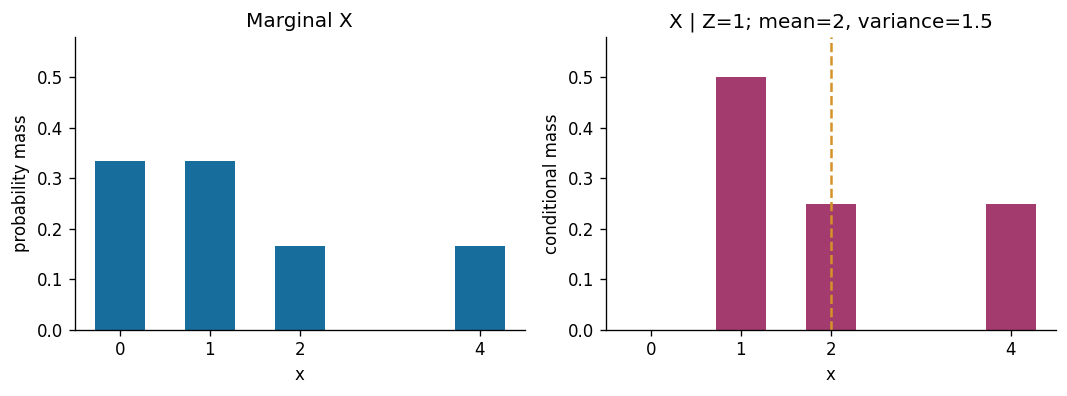

In [3]:
quiet = e.conditional_finite(D,p,1,0)
active = e.conditional_finite(D,p,1,1)
print('quiet mean / covariance:', quiet['mean'], quiet['covariance'])
print('active mean / covariance:', active['mean'], active['covariance'])
fig, axes = plt.subplots(1,2,figsize=(9,3.4))
xs = [0,1,2,4]
axes[0].bar(xs,[marginal_x[x] for x in xs],color='#176d9c',width=.55)
axes[0].set(title='Marginal X',xlabel='x',ylabel='probability mass',xticks=xs,ylim=(0,.58))
conditional_x = [math.fsum(weight for row,weight in zip(active['states'],active['probabilities']) if row[0]==x) for x in xs]
axes[1].bar(xs,conditional_x,color='#a43b6e',width=.55)
axes[1].axvline(2,color='#d59228',ls='--')
axes[1].set(title='X | Z=1; mean=2, variance=1.5',xlabel='x',ylabel='conditional mass',xticks=xs,ylim=(0,.58))
fig.tight_layout(); display(fig); plt.close(fig)

### 3 用两条独立路径核对协方差
实现按中心乘积计算；这里另用Fraction计算原始矩E[XZ]−E[X]E[Z]。这两种写法数学相等，但浮点大数消减风险不同。

In [4]:
rational_rows = [[F(int(x)),F(int(z))] for x,z in D]
rational_p = [F(1,6)]*6
exact_mean = [sum(q*row[j] for q,row in zip(rational_p,rational_rows)) for j in range(2)]
exact_cov = [[sum(q*row[i]*row[j] for q,row in zip(rational_p,rational_rows))-exact_mean[i]*exact_mean[j] for j in range(2)] for i in range(2)]
print('exact mean:', [str(v) for v in exact_mean])
print('exact covariance:', [[str(v) for v in row] for row in exact_cov])
print('float covariance:', model['covariance'])
print('rho:', e.correlation(model['covariance'])[0,1])
print('X+Z and X-Z covariance:',e.linear_moments(model['mean'],model['covariance'],[[1,1],[1,-1]],[0,0])['covariance'])

exact mean: ['4/3', '2/3']
exact covariance: [['17/9', '4/9'], ['4/9', '2/9']]
float covariance: [[1.88888889 0.44444444]
 [0.44444444 0.22222222]]
rho: 0.6859943405700355
X+Z and X-Z covariance: [[3.         1.66666667]
 [1.66666667 1.22222222]]


### 4 样本的形状和分母
CᵀC/n是2×2；CCᵀ/n是6×6的另一种Gram矩阵。ddof=1把本例放大6/5，不能把默认参数差别当作计算误差。

In [5]:
C = D-D.mean(axis=0)
print('D shape:',D.shape,'C.T @ C shape:',(C.T@C).shape,'C @ C.T shape:',(C@C.T).shape)
print('ddof=0:',e.sample_covariance(D,ddof=0)['covariance'])
print('ddof=1:',e.sample_covariance(D,ddof=1)['covariance'])
print('explicit NumPy:',np.cov(D,rowvar=False,ddof=0))
print('rank(C):',np.linalg.matrix_rank(C),'upper bound:',min(D.shape[1],D.shape[0]-1))

D shape: (6, 2) C.T @ C shape: (2, 2) C @ C.T shape: (6, 6)
ddof=0: [[1.88888889 0.44444444]
 [0.44444444 0.22222222]]
ddof=1: [[2.26666667 0.53333333]
 [0.53333333 0.26666667]]
explicit NumPy: [[1.88888889 0.44444444]
 [0.44444444 0.22222222]]
rank(C): 2 upper bound: 2


### 5 先检查对称和半正定
矩阵[[1,2],[2,1]]会让(1,−1)方向的方差为−2。不对称矩阵不能只靠Cholesky成功就验收。本单元不投影、不加jitter；数值上过于接近奇异的正定矩阵也明确拒绝。

In [6]:
for label,covariance in [('negative direction',[[1,2],[2,1]]),('asymmetric',[[1,.1],[.2,1]]),('singular',[[1,2],[2,4]])]:
    try:
        e.covariance_matrix(covariance,strictly_positive=True)
    except ValueError as error:
        print(label,'->',str(error))
a=np.array([1.,-1.])
print('invalid directional variance:',a@np.array([[1.,2.],[2.,1.]])@a)

negative direction -> negative computed covariance eigenvalue; no PSD repair
asymmetric -> covariance must be exactly symmetric; no automatic symmetrization
singular -> strict PD numerical interface requires lambda_min/lambda_max > 1e-12
invalid directional variance: -2.0


### 6 固定种子的八个实验
每个模型n=12000，种子2101至2108。每种模型使用独立命名的随机流，避免改变一个样本数意外移动其他模型的流。运行只在内存生成数据；命令行脚本另会保存完整CSV。

In [7]:
report,samples = e.generate_experiment(n=12000)
print('n each:',report['n_each'],'ddof:',report['sample_ddof'])
print('seeds:',report['seeds'])
print('Gaussian empirical mean:',report['empirical']['gaussian']['mean'])
print('Gaussian empirical covariance:',report['empirical']['gaussian']['covariance'])
print('conditional x=5 empirical:',report['empirical']['conditional_x5'])

n each: 12000 ddof: 0
seeds: {'finite': 2101, 'gaussian': 2102, 'triangle': 2103, 'nonlinear': 2104, 'normal_marginals': 2105, 'independent_normal': 2106, 'conditional_x5': 2107, 'singular': 2108}
Gaussian empirical mean: [1.0168374482843459, -1.9873289698073617]
Gaussian empirical covariance: [[3.998253250832052, 3.029731928577153], [3.029731928577153, 9.040679593798835]]
conditional x=5 empirical: {'n': 12000, 'd': 1, 'ddof': 0, 'mean': [0.9968658517110714], 'covariance': [[6.808712305019663]]}


### 7 生成方向由因子决定
下三角L满足LLᵀ=Σ。行向量噪声使用E@L.T。下图中理论矩阵与经验矩阵分开标注；不要求二者逐位相等。

L: [[2.         0.        ]
 [1.5        2.59807621]]
L @ L.T: [[4. 3.]
 [3. 9.]]


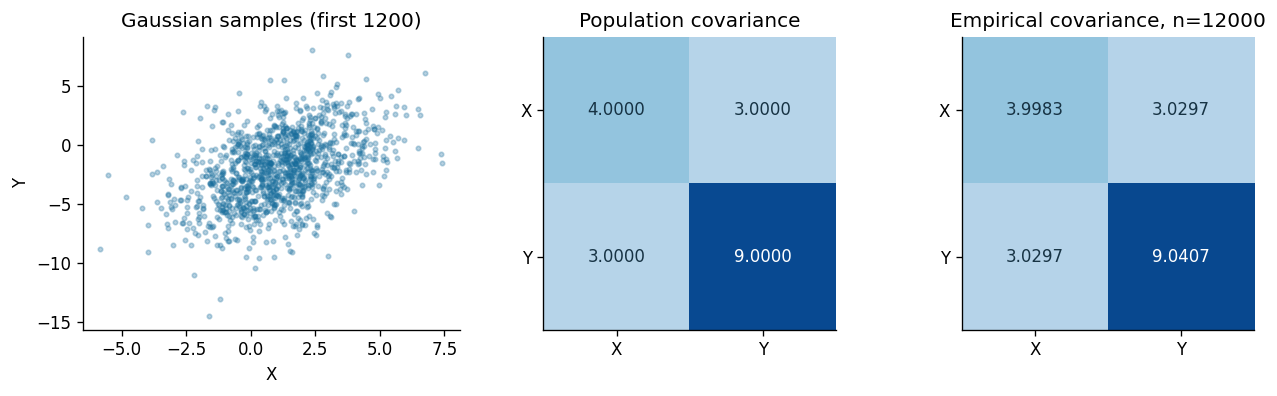

In [8]:
gaussian = e.load_gaussian()
print('L:',gaussian['factor'])
print('L @ L.T:',gaussian['factor']@gaussian['factor'].T)
empirical=np.array(report['empirical']['gaussian']['covariance'])
fig,axes=plt.subplots(1,3,figsize=(11,3.4))
axes[0].scatter(samples['gaussian'][:1200,0],samples['gaussian'][:1200,1],s=7,alpha=.3,color='#176d9c')
axes[0].set(xlabel='X',ylabel='Y',title='Gaussian samples (first 1200)')
for ax,matrix,title in [(axes[1],gaussian['covariance'],'Population covariance'),(axes[2],empirical,'Empirical covariance, n=12000')]:
    ax.imshow(matrix,cmap='Blues',vmin=0,vmax=10)
    ax.set(xticks=[0,1],yticks=[0,1],xticklabels=['X','Y'],yticklabels=['X','Y'],title=title)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f'{matrix[i,j]:.4f}',ha='center',va='center',color='white' if matrix[i,j]>5 else '#173344')
fig.tight_layout();display(fig);plt.close(fig)

### 8 密度积分的两个误差来源
积分域选μ+L[-6,6]²，它是变换后的平行四边形。变换体积乘数为det(L)=√27。域外质量由一维正态CDF给出1−erf(6/√2)²；离散网格误差另与域内解析质量比较。粗细网格差本身不是已知误差上界。

In [9]:
retained=math.erf(6/math.sqrt(2))**2
quadrature=[]
for steps in [60,120]:
    axis=np.linspace(-6,6,steps+1)
    xx,yy=np.meshgrid(axis,axis,indexing='ij')
    white=np.column_stack((xx.ravel(),yy.ravel()))
    points=white@gaussian['factor'].T+gaussian['mean']
    f=e.gaussian_pdf(points,gaussian['mean'],gaussian['covariance']).reshape(xx.shape)*math.sqrt(27)
    integral=float(np.trapezoid(np.trapezoid(f,axis,axis=1),axis))
    quadrature.append({'steps':steps,'integral':integral,'absolute_grid_error':abs(integral-retained)})
print('analytic retained mass:',retained,'omitted tail:',1-retained)
print(quadrature)

analytic retained mass: 0.9999999960536494 omitted tail: 3.946350579653313e-09
[{'steps': 60, 'integral': 0.9999999955779859, 'absolute_grid_error': 4.756635085811922e-10}, {'steps': 120, 'integral': 0.9999999959327955, 'absolute_grid_error': 1.2085388245708373e-10}]


### 9 零相关不等于独立
离散U²反例用事件概率精确反驳分解。G与SG反例的两个边缘都正态，却满足绝对值相同；有限样本相关不会被强制改成0。

Cov(U,U^2): 0.0
joint event: 1/3 product of marginals: 1/9
normal-marginal absolute-value identity: True


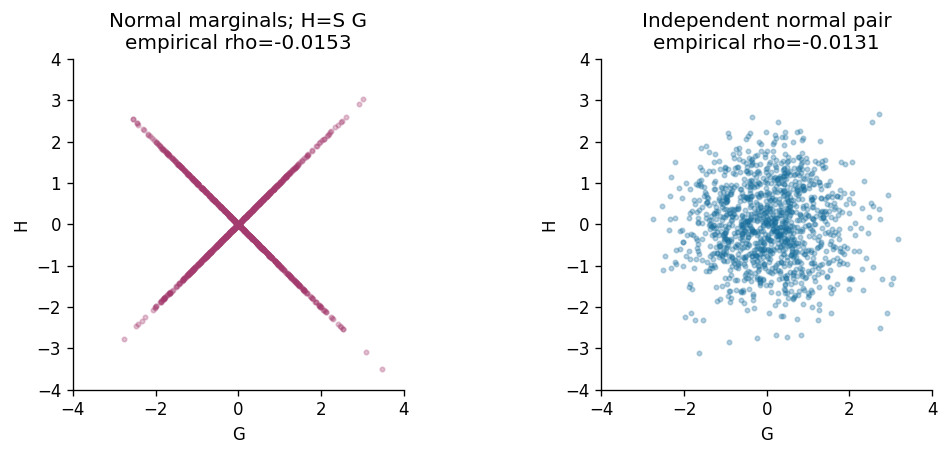

In [10]:
nonlinear=e.finite_moments([[-1,1],[0,0],[1,1]],[F(1,3)]*3)
print('Cov(U,U^2):',nonlinear['covariance'][0,1])
print('joint event:',F(1,3),'product of marginals:',F(1,9))
print('normal-marginal absolute-value identity:',np.array_equal(np.abs(samples['normal_marginals'][:,0]),np.abs(samples['normal_marginals'][:,1])))
fig,axes=plt.subplots(1,2,figsize=(9,3.9))
for ax,key,col,title in [(axes[0],'normal_marginals','#a43b6e','Normal marginals; H=S G'),(axes[1],'independent_normal','#176d9c','Independent normal pair')]:
    points=samples[key]
    cov=e.sample_covariance(points)['covariance']
    rho=cov[0,1]/np.sqrt(cov[0,0]*cov[1,1])
    ax.scatter(points[:1200,0],points[:1200,1],s=7,alpha=.3,color=col)
    ax.set(xlim=(-4,4),ylim=(-4,4),xlabel='G',ylabel='H',title=title+f'\nempirical rho={rho:.4f}')
    ax.set_aspect('equal')
fig.tight_layout();display(fig);plt.close(fig)

### 10 精确条件高斯不等于有限宽切片
给定x=5，直接从N(1,27/4)生成条件样本。若改筛4.5<X<5.5，将混合一段不同的条件均值，这个实验不能声称得到精确X=5。第二参数27/4是方差。

conditional mean, covariance: [1.] [[6.75]]
residual cross covariance: [[0.]]


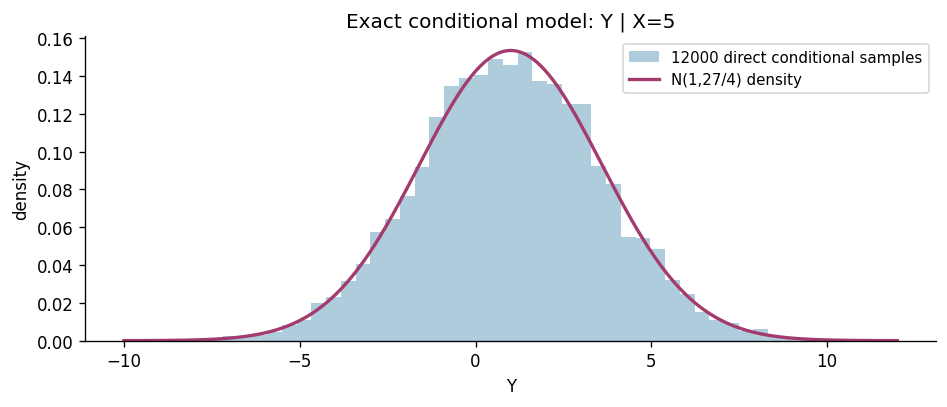

In [11]:
conditional=e.gaussian_conditional([1,-2],[[4,3],[3,9]],[0],[5])
print('conditional mean, covariance:',conditional['mean'],conditional['covariance'])
print('residual cross covariance:',conditional['residual_cross_covariance'])
y=np.linspace(-10,12,400)
f=e.gaussian_pdf(y[:,None],conditional['mean'],conditional['covariance'])
fig,ax=plt.subplots(figsize=(8,3.5))
ax.hist(samples['conditional_x5'][:,0],bins=45,density=True,color='#176d9c',alpha=.35,label='12000 direct conditional samples')
ax.plot(y,f,color='#a43b6e',lw=2,label='N(1,27/4) density')
ax.set(xlabel='Y',ylabel='density',title='Exact conditional model: Y | X=5');ax.legend(fontsize=9)
fig.tight_layout();display(fig);plt.close(fig)

### 11 奇异高斯仍可生成
用B=(1,2)ᵀ与一个标准正态，得到Y=2X。二维协方差奇异，但构造有意义。不能在平面上套普通二维高斯密度。

In [12]:
singular=e.sample_gaussian_factor([0,0],[[1],[2]],12000,2108)
print('factor covariance:',singular['covariance'])
print('all rows satisfy Y=2X:',np.array_equal(singular['rows'][:,1],2*singular['rows'][:,0]))
try:
    e.gaussian_pdf([[0,0]],[0,0],[[1,2],[2,4]])
except ValueError as error:
    print('ordinary density rejected:',str(error))

factor covariance: [[1. 2.]
 [2. 4.]]
all rows satisfy Y=2X: True
ordinary density rejected: strict PD numerical interface requires lambda_min/lambda_max > 1e-12


### 12 三角密度的条件方差随x改变
排序两个独立Uniform(0,1)后取X为较大者、Y为较小者。两种原排列映到同一三角形，因此密度为2。与高斯条件不同，Var(Y|X=x)=x²/12。

triangle empirical: {'n': 12000, 'd': 2, 'ddof': 0, 'mean': [0.6626832335071805, 0.32955261005205483], 'covariance': [[0.055693718665543075, 0.027987481625634313], [0.027987481625634313, 0.05533546309380181]]}
triangle theory: {'mean': [0.6666666666666666, 0.3333333333333333], 'covariance': [[0.05555555555555555, 0.027777777777777776], [0.027777777777777776, 0.05555555555555555]], 'within_y_given_x': 0.041666666666666664, 'between_y_given_x': 0.013888888888888888}


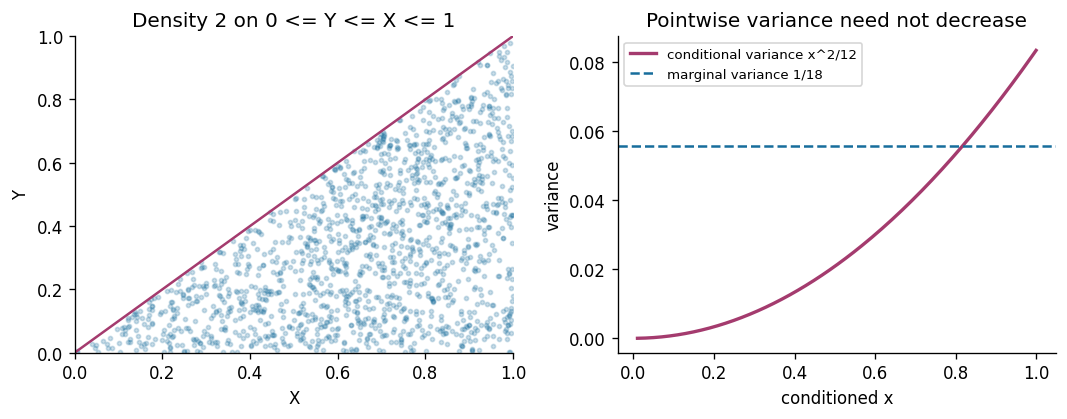

In [13]:
print('triangle empirical:',report['empirical']['triangle'])
print('triangle theory:',report['triangle_theory'])
fig,axes=plt.subplots(1,2,figsize=(9,3.6))
points=samples['triangle'][:1500]
axes[0].scatter(points[:,0],points[:,1],s=6,alpha=.22,color='#176d9c')
axes[0].plot([0,1],[0,1],color='#a43b6e')
axes[0].set(xlabel='X',ylabel='Y',title='Density 2 on 0 <= Y <= X <= 1',xlim=(0,1),ylim=(0,1))
x=np.linspace(.01,1,200)
axes[1].plot(x,x*x/12,color='#a43b6e',lw=2,label='conditional variance x^2/12')
axes[1].axhline(1/18,color='#176d9c',ls='--',label='marginal variance 1/18')
axes[1].set(xlabel='conditioned x',ylabel='variance',title='Pointwise variance need not decrease');axes[1].legend(fontsize=8)
fig.tight_layout();display(fig);plt.close(fig)

### 13 全方差的组概率不能省略
组内为1，组间为8/9，总体17/9。第二个反例用10%的高方差组说明：平均减少方差不表示每个组都减少。

{'total': 1.888888888888889, 'within': 1.0, 'between': 0.8888888888888888, 'groups': [{'label': 0.0, 'probability': 0.3333333333333333, 'mean': 0.0, 'variance': 0.0}, {'label': 1.0, 'probability': 0.6666666666666666, 'mean': 2.0, 'variance': 1.5}], 'probability_audit': {'input_total': 1.0, 'tolerance': 1.7763568394002505e-15, 'maximum_adjustment': 0.0, 'used_total': 1.0}}
rare-group example: {'total': 10.0, 'within': 10.0, 'between': 0.0, 'groups': [{'label': 0.0, 'probability': 0.9, 'mean': 0.0, 'variance': 0.0}, {'label': 1.0, 'probability': 0.1, 'mean': 0.0, 'variance': 100.0}], 'probability_audit': {'input_total': 1.0, 'tolerance': 1.7763568394002505e-15, 'maximum_adjustment': 0.0, 'used_total': 1.0}}


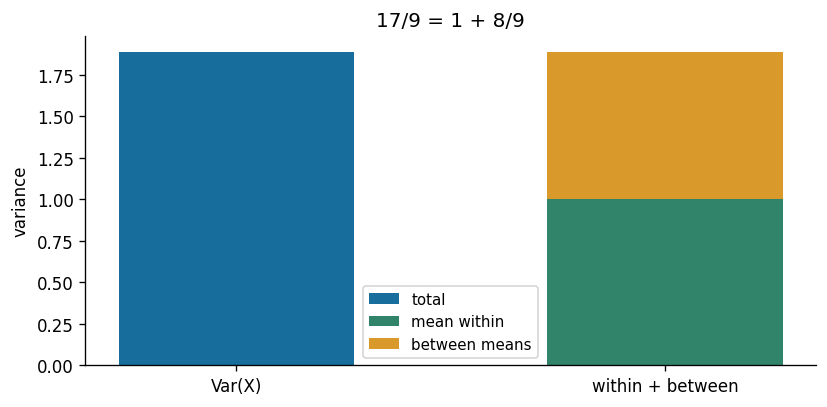

In [14]:
decomposition=e.total_variance(D,p,0,1)
print(decomposition)
rare=e.total_variance([[0,0],[-10,1],[10,1]],[.9,.05,.05],0,1)
print('rare-group example:',rare)
fig,ax=plt.subplots(figsize=(7,3.5))
ax.bar([0],[decomposition['total']],width=.55,color='#176d9c',label='total')
ax.bar([1],[decomposition['within']],width=.55,color='#31846a',label='mean within')
ax.bar([1],[decomposition['between']],bottom=[decomposition['within']],width=.55,color='#d99a2b',label='between means')
ax.set(xticks=[0,1],xticklabels=['Var(X)','within + between'],ylabel='variance',title='17/9 = 1 + 8/9');ax.legend(fontsize=9)
fig.tight_layout();display(fig);plt.close(fig)

## Checks
### 14 精确参考与失败输入同样要验收
运行独立Fraction与Decimal参考、概率舍入复用、整个支持集的类型检查、115个非法输入组和65个随机流创建之前的拒绝检查。检查使用显式异常；python -O不会移除它们。

In [15]:
checks=run_checks()
print(json.dumps(checks,ensure_ascii=False,indent=2))

{
  "status": "passed",
  "numeric_checks": 1358,
  "rejection_checks": 115,
  "pre_rng_checks": 65,
  "references": "Fraction finite-model raw moments and direct projections; rational 2D/block conditionals; Decimal center density; explicit componentwise sampler",
  "quadrature": {
    "domain": "mu+L[-6,6]^2",
    "steps_per_axis": [
      60,
      120
    ],
    "estimates": [
      0.9999999955779859,
      0.9999999959327955
    ],
    "analytic_retained_mass": 0.9999999960536494,
    "omitted_tail_mass": 3.946350579653313e-09,
    "absolute_grid_errors": [
      4.756635085811922e-10,
      1.2085388245708373e-10
    ]
  },
  "no_assert_statements": true,
  "python_optimized_mode_supported": true
}


### 15 主动触发两种常见错误
混合bool和数字必须在浮点强制转换前拒绝；远尾密度应改用logpdf，不能把数值下溢0当作模型在支持外的精确0。

In [16]:
for name,call in [('mixed bool',lambda:e.sample_finite([[0,0],[True,1]],[1,0],1)),
                  ('far-tail ordinary PDF',lambda:e.gaussian_pdf([[1000,1000]],[0,0],[[1,0],[0,1]]))]:
    try:
        call()
    except ValueError as error:
        print(name,'->',str(error))
print('far-tail logpdf:',e.gaussian_logpdf([[1000,1000]],[0,0],[[1,0],[0,1]]))

mixed bool -> states requires real numbers; bool, strings, complex and objects are rejected
far-tail ordinary PDF -> density would be subnormal or underflow; use gaussian_logpdf
far-tail logpdf: [-1000001.83787707]


## Next Steps
先独立完成answers.pdf中的18题，再核对详解。尝试只打乱X列而固定Z列，解释边缘不变而联合改变；尝试改变线性组合的系数，说明方差的交叉项为何可增可减。要改模型，请使用可复用API并同步重算理论，CLI会拒绝与本讲固定参考不一致的数据文件。

本Notebook在独立新Python进程中的真实IPython InProcessKernel顺序执行，保留16个代码单元输出及6幅PNG。未测试浏览器Jupyter界面、socket传输、读者机器上的Anaconda安装、跨NumPy版本逐位复现。图形与数值近似均不替代关于独立、正态或极限定理的证明。

### 一手来源
正文source-checks.json记录各材料的实际阅读范围。接口语义见[NumPy cov](https://numpy.org/doc/2.3/reference/generated/numpy.cov.html)、[Cholesky](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.cholesky.html)与[eigh](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.eigh.html)。多元Gaussian构造及条件公式核对[MIT 6.436J 第14讲](https://ocw.mit.edu/courses/6-436j-fundamentals-of-probability-fall-2018/ceb423b6a703abd60429367b733f45bf_MIT6_436JF18_lec14.pdf)。